In [5]:
import os
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
zip_path="/content/Plant_Disease_Workshop.zip"
extract_path="/content"
with zipfile.ZipFile(zip_path,'r') as zip_ref:
  zip_ref.extractall(extract_path)
print("Dataset Extracted successfully!")


Dataset Extracted successfully!


In [6]:
dataset_path="/content/Plant_Disease_Workshop"
print(os.listdir(dataset_path))

['val', 'train']


In [7]:
dataset_path="/content/Plant_Disease_Workshop/train"
print(os.listdir(dataset_path))

['Potato___Late_blight', 'Potato___Early_blight', 'Potato___healthy']


In [8]:
dataset_path="/content/Plant_Disease_Workshop/val"
print(os.listdir(dataset_path))

['Potato___Late_blight', 'Potato___Early_blight', 'Potato___healthy']


In [27]:
print("===========TRAIN DATA============\n")
for folder in os.listdir(train_path):
  folder_path=os.path.join(train_path,folder)
  print(folder,":",len(os.listdir(folder_path)),"images")

===========TRAIN DATA============

Potato___Late_blight : 800 images
Potato___Early_blight : 800 images
Potato___healthy : 121 images


In [14]:
val_path = "/content/Plant_Disease_Workshop/val"
print("===========VALTIOn DATA============\n")
for folder in os.listdir(val_path):
  folder_path=os.path.join(val_path,folder)
  print(folder,":",len(os.listdir(folder_path)),"images")

===========VALTIOn DATA============

Potato___Late_blight : 200 images
Potato___Early_blight : 200 images
Potato___healthy : 31 images


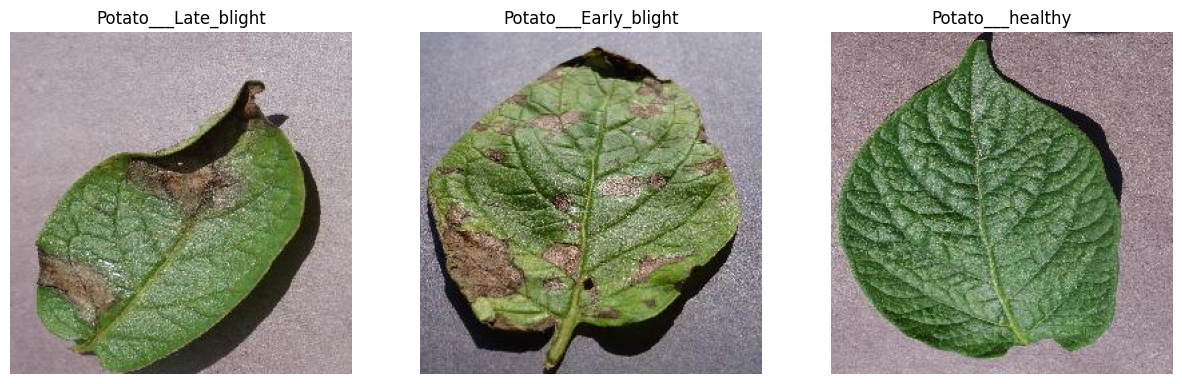

In [26]:
plt.figure(figsize=(15,5))
classes = os.listdir(train_path)
for i,folder in enumerate(classes):
  image_name = os.listdir(os.path.join(train_path,folder))[0]
  image_path = os.path.join(train_path,folder,image_name)
  image = cv2.imread(image_path)
  image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
  plt.subplot(1,3,i+1)
  plt.imshow(image)
  plt.title(folder)
  plt.axis("off")
plt.show()

In [22]:
train_path = "/content/Plant_Disease_Workshop/train"
val_path = "/content/Plant_Disease_Workshop/val"
image_size = (64,64)


In [23]:
X_train=[]
y_train=[]

X_val=[]
y_val=[]

In [24]:
for label in os.listdir(train_path):
  folder_path=os.path.join(train_path,label)
  for image_name in os.listdir(folder_path):
    image_path=os.path.join(folder_path,image_name)
    image=cv2.imread(image_path)
    image=cv2.resize(image,image_size)
    X_train.append(image)
    y_train.append(label)
print("Training images loaded successfully!")

Training images loaded successfully!


In [25]:
for label in os.listdir(val_path):
  folder_path=os.path.join(val_path,label)
  for image_name in os.listdir(folder_path):
    image_path=os.path.join(folder_path,image_name)
    image=cv2.imread(image_path)
    image=cv2.resize(image,image_size)
    X_val.append(image)
    y_val.append(label)
print("Validation images loaded successfully!")

Validation images loaded successfully!


In [28]:
print("Training images:",len(X_train))
print("Training lebal:",len(y_train))
print()
print("Validation images:",len(X_val))
print("Validation lebal:",len(y_val))



Training images: 1721
Training lebal: 1721

Validation images: 431
Validation lebal: 431


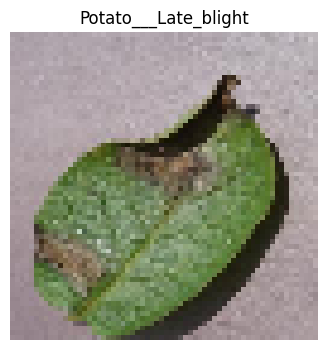

In [29]:
plt.figure(figsize=(4,4))
plt.imshow(cv2.cvtColor(X_train[0],cv2.COLOR_BGR2RGB))
plt.title(y_train[0])
plt.axis("off")
plt.show()


In [30]:
X_train=np.array(X_train)
y_train=np.array(y_train)
X_val=np.array(X_val)
y_val=np.array(y_val)
print("Converted Successfully")

Converted Successfully


In [31]:
print("Training shap:",X_train.shape)
print("Validation shap:",X_val.shape)

Training shap: (1721, 64, 64, 3)
Validation shap: (431, 64, 64, 3)


In [32]:
X_train=X_train.reshape(X_train.shape[0],-1)
X_val=X_val.reshape(X_val.shape[0],-1)
print("Images flattened successfully!")
print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)


Images flattened successfully!
Training shape: (1721, 12288)
Validation shape: (431, 12288)


In [33]:
X_train=X_train/255.0
X_val=X_val/255.0
print("Normalization completed!")

Normalization completed!


In [34]:
from cv2.cuda import printCudaDeviceInfo
encoder=LabelEncoder()
y_train=encoder.fit_transform(y_train)
y_val=encoder.fit_transform(y_val)
print("Label encoded successfully!")
print("Encoded Classes:")
print(encoder.classes_)
print()
print("First 10 Labels:")
print(y_train[:10])

Label encoded successfully!
Encoded Classes:
['Potato___Early_blight' 'Potato___Late_blight' 'Potato___healthy']

First 10 Labels:
[1 1 1 1 1 1 1 1 1 1]


In [35]:
print("training features shape:",X_train.shape)
print("training labels shape:",y_train.shape)
print()
print("validation features shape:",X_val.shape)
print("validation labels shape:",y_val.shape)


training features shape: (1721, 12288)
training labels shape: (1721,)

validation features shape: (431, 12288)
validation labels shape: (431,)


In [36]:
logistic_model=LogisticRegression(max_iter=1000)
logistic_model.fit(X_train,y_train)
print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [37]:
y_pred=logistic_model.predict(X_val)
print("Prediction Completed")

Prediction Completed


In [38]:
print("Actual Labels:",y_val[:10])
print("Predicted Labels:",y_pred[:10])

Actual Labels: [1 1 1 1 1 1 1 1 1 1]
Predicted Labels: [1 1 1 1 1 1 1 1 1 1]


In [41]:
acc = accuracy_score(y_val,y_pred)
print("Accuracy :",round(acc*100,2),"%")

Accuracy : 90.95 %


In [42]:
#confusion matrix
cmx=confusion_matrix(y_val,y_pred)
print("Confusion Matrix:")
print(cmx)

Confusion Matrix:
[[186  14   0]
 [  8 189   3]
 [  0  14  17]]


In [43]:
print(classification_report(y_val,y_pred,target_names=encoder.classes_))

                       precision    recall  f1-score   support

Potato___Early_blight       0.96      0.93      0.94       200
 Potato___Late_blight       0.87      0.94      0.91       200
     Potato___healthy       0.85      0.55      0.67        31

             accuracy                           0.91       431
            macro avg       0.89      0.81      0.84       431
         weighted avg       0.91      0.91      0.91       431



In [44]:
predicted_labels=encoder.inverse_transform(y_pred[:10])
print("Predicted Labels:")
print(predicted_labels)


Predicted Labels:
['Potato___Late_blight' 'Potato___Late_blight' 'Potato___Late_blight'
 'Potato___Late_blight' 'Potato___Late_blight' 'Potato___Late_blight'
 'Potato___Late_blight' 'Potato___Late_blight' 'Potato___Late_blight'
 'Potato___Late_blight']


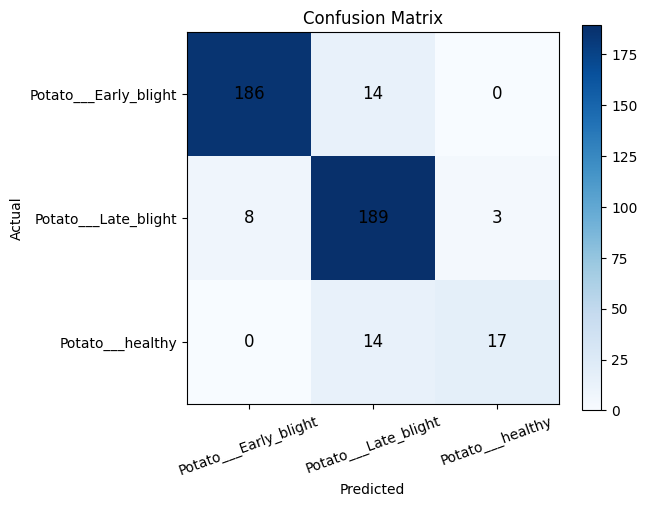

In [53]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
plt.imshow(cmx,cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(range(3),encoder.classes_,rotation=20)
plt.yticks(range(3),encoder.classes_)

for i in range(len(cmx)):
  for j in range(len(cmx)):
    plt.text(j,i,cmx[i,j],
             ha="center",
             va="center",
             color="black" ,
             fontsize=12)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [54]:
print("="*40)
print("Logistic regression completed successfully")
print("="*40)
print(f"Accuracy:{acc*100:.2f}%")


Logistic regression completed successfully
Accuracy:90.95%


In [55]:
svm_model=SVC(kernel="linear")
print("support Vector Machine trained successfully!")

support Vector Machine trained successfully!


In [58]:
svm_model.fit(X_train,y_train)
print("SVM trained successfully!")


SVM trained successfully!


In [59]:
y_pred=svm_model.predict(X_val)
print("Prediction Completed")

Prediction Completed


In [75]:
acc=accuracy_score(y_val,y_pred)
print(f"Accuracy:{acc*100:.2f}%")


Accuracy:91.18%


In [76]:
svm_cmx=confusion_matrix(y_val,y_pred)
print("Confusion Matrix:")
print(cmx)

Confusion Matrix:
[[183  17   0]
 [  9 188   3]
 [  1   8  22]]


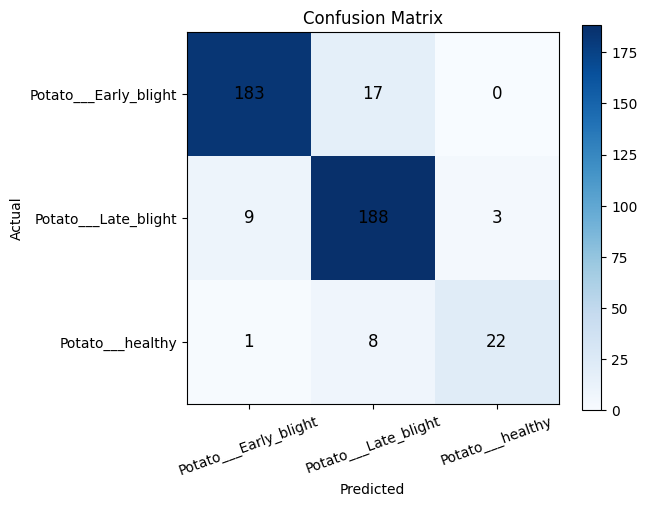

In [77]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
plt.imshow(cmx,cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(range(3),encoder.classes_,rotation=20)
plt.yticks(range(3),encoder.classes_)

for i in range(len(cmx)):
  for j in range(len(svm_cmx)):
    plt.text(j,i,cmx[i,j],
             ha="center",
             va="center",
             color="black",fontsize=12)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [78]:
print("="*40)
print("SVM regression completed successfully")
print("="*40)
print(f"Accuracy:{acc*100:.2f}%")

SVM regression completed successfully
Accuracy:91.18%


In [80]:
from google.colab import files
uploaded = files.upload()

Saving OIP (5).webp to OIP (5) (1).webp


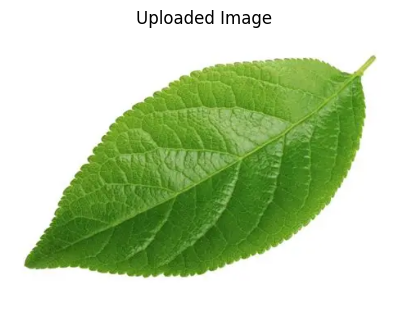

In [81]:
image_name=list(uploaded.keys())[0]

image=cv2.imread(image_name)
image_rgb= cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
plt.figure(figsize=(5,5))
plt.imshow(image_rgb)
plt.title("Uploaded Image")
plt.axis("off")
plt.show()


In [83]:
test_image=cv2.resize(image,(64,64))
test_image =test_image.reshape(1,-1)
test_image = test_image / 255.0
print("Image preprocessed successfully!")


Image preprocessed successfully!


In [86]:
prediction=svm_model.predict(test_image)
predicted_disease=encoder.inverse_transform(prediction)
print("Predicted Disease:",predicted_disease[0])


Predicted Disease: Potato___healthy


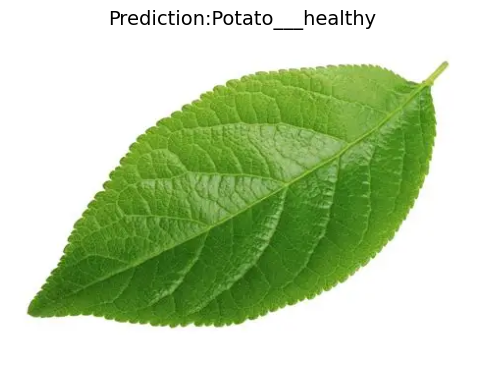

In [88]:
plt.figure(figsize=(6,6))
plt.imshow(image_rgb)
plt.title("Prediction:" + predicted_disease[0],fontsize=14)
plt.axis("off")
plt.show()

In [89]:
if predicted_disease[0]== "Potato___Early_blight":
  print("Disease :Potato___Early_blight")
  print("Advice:Remove infected leaves and apply  suitable fungicide.")

elif predicted_disease[0]== "Potato___Late_blight":
  print("Disease :Potato___Late_blight")
  print("Advice:Improve drainage, avoid overhead watering, and recommended .")
elif predicted_disease[0]== "Potato___healthy":
  print("Potato___healthy")
  print("Advice:No action required")

Potato___healthy
Advice:No action required


In [90]:
logistic_regression_accuracy_value = 0.9095
comparison ={
    "Model":["logistic Regression","SVM"],
    "Accuracy":[logistic_regression_accuracy_value * 100, acc * 100]
}
import pandas as pd
comparison_df = pd.DataFrame(comparison)
print(comparison_df)

                 Model   Accuracy
0  logistic Regression  90.950000
1                  SVM  91.183295


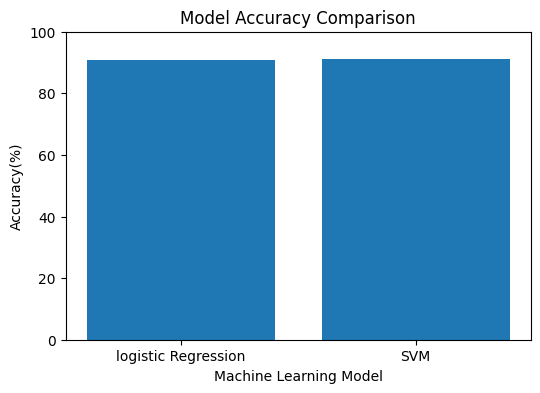

In [92]:
plt.figure(figsize=(6, 4))
plt.bar(comparison_df['Model'],comparison_df['Accuracy'])
plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy(%)")
plt.ylim(0,100)
plt.show()

In [94]:
if acc > logistic_regression_accuracy_value:
  print("Best Model: support vector Machine(SVM)")
else:
  print("Best Model: Logistic regression")


Best Model: support vector Machine(SVM)
